# LeetCode #104: Maximum Depth of Binary Tree

https://leetcode.com/problems/maximum-depth-of-binary-tree/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| BFS Level Count | O(n) | O(n) | Count BFS iterations |
| Iterative DFS (Stack) | O(n) | O(n) | Track (node, depth) on stack |
| **DFS Recursive ★** | **O(n)** | **O(n)** | `1 + max(left, right)` — cleanest |

---

## Understanding the Methods

### Brute Force (BFS)
Use a BFS queue. Count how many levels we process. Each complete level iteration increments a counter. Return the counter.

### DFS Recursive (Optimal ★)
The key insight: `maxDepth(node) = 1 + max(maxDepth(node.left), maxDepth(node.right))`. Base case: null node returns 0. This naturally bubbles the maximum depth up from leaves to root.

## Constraints
- Number of nodes: [0, 10⁴]
- Node values: [-100, 100]

## Solutions

### C#

In [ ]:
public class Solution {
    public int MaxDepth(TreeNode root) {
        if (root == null) return 0;
        return 1 + Math.Max(MaxDepth(root.left), MaxDepth(root.right));
    }
}

### Python

In [ ]:
class Solution:
    def maxDepth(self, root) -> int:
        if not root:
            return 0
        return 1 + max(self.maxDepth(root.left), self.maxDepth(root.right))

### Go

In [ ]:
func maxDepth(root *TreeNode) int {
    if root == nil { return 0 }
    left  := maxDepth(root.Left)
    right := maxDepth(root.Right)
    if left > right { return 1 + left }
    return 1 + right
}

### Rust

In [ ]:
use std::rc::Rc;
use std::cell::RefCell;

impl Solution {
    pub fn max_depth(root: Option<Rc<RefCell<TreeNode>>>) -> i32 {
        match root {
            None => 0,
            Some(node) => {
                let left  = Self::max_depth(node.borrow().left.clone());
                let right = Self::max_depth(node.borrow().right.clone());
                1 + left.max(right)
            }
        }
    }
}

## Example Scenarios

### 1. Common Case — Balanced 3-Level Tree
**Input:** `root = [3, 9, 20, null, null, 15, 7]`

DFS recurses: maxDepth(3) = 1 + max(maxDepth(9), maxDepth(20)). maxDepth(9) = 1 + max(0,0) = 1. maxDepth(20) = 1 + max(1,1) = 2. So maxDepth(3) = 1 + max(1,2) = 3.

WHY: Baseline case with uneven subtrees (right is deeper). The $\max()$ correctly selects the right branch's depth.

$1 + \max(1, 2) = 3$

**Output:** `3`

---

### 2. Slightly Complex — Zigzag Path (left-right-left)
**Input:** `root = [1, 2, null, null, 3, 4]` (1→2.left→3.right→4.left)

Deepest path zigzags: 1→2→3→4. Each node has only one child, creating depth 4 with only 4 nodes. The max() at each level trivially selects the non-zero branch.

WHY: Mixed left/right children prevent naive "always go left" shortcuts. Depth 4 with only 4 nodes — a degenerate tree that looks deeper than expected.

$1 + \max(3, 0) = 4$

**Output:** `4`

---

### 3. Edge Case: Time Factor — Right-Skewed Chain of 10,000 Nodes
**Input:** `root = 1 → 2 → 3 → ... → 10000` (right children only)

DFS makes 10,000 recursive calls before hitting base case. Each returns $1 + \text{child}$. Total time = $O(n) = O(10{,}000)$. Recursion depth = 10,000 stack frames.

WHY: Maximum $n = 10^4$ as a degenerate chain. Tests both time (full traversal) and stack depth. In languages without TCO, this risks stack overflow — an important interview point.

**Output:** `10000`

---

### 4. Edge Case: Space Factor — Perfect Tree of ~10,000 Nodes
**Input:** `root = perfect binary tree, ~10000 nodes, depth ≈ 13`

Recursion depth = $O(\log n) = 13$. Stack space is minimal despite large n. DFS visits all 10,000 nodes but the call stack never exceeds 13 frames.

WHY: Same n as example 3 but radically different space: $O(\log n)$ vs $O(n)$. Demonstrates that space depends on tree shape, not node count. Interviewers want candidates to distinguish these cases.

**Output:** `13` (for 8191 nodes) or `14` (for 10000 nodes)

---

### 5. Almost-Impossible but Plausible — Null Root (Empty Tree)
**Input:** `root = null`

Hits the base case immediately: return 0. No recursion. Time and space are both $O(1)$. The constraint allows 0 nodes.

WHY: If the base case check is after accessing root.val or root.left, it crashes with a null pointer exception. Tests defensive coding at the function entry point.

**Output:** `0`

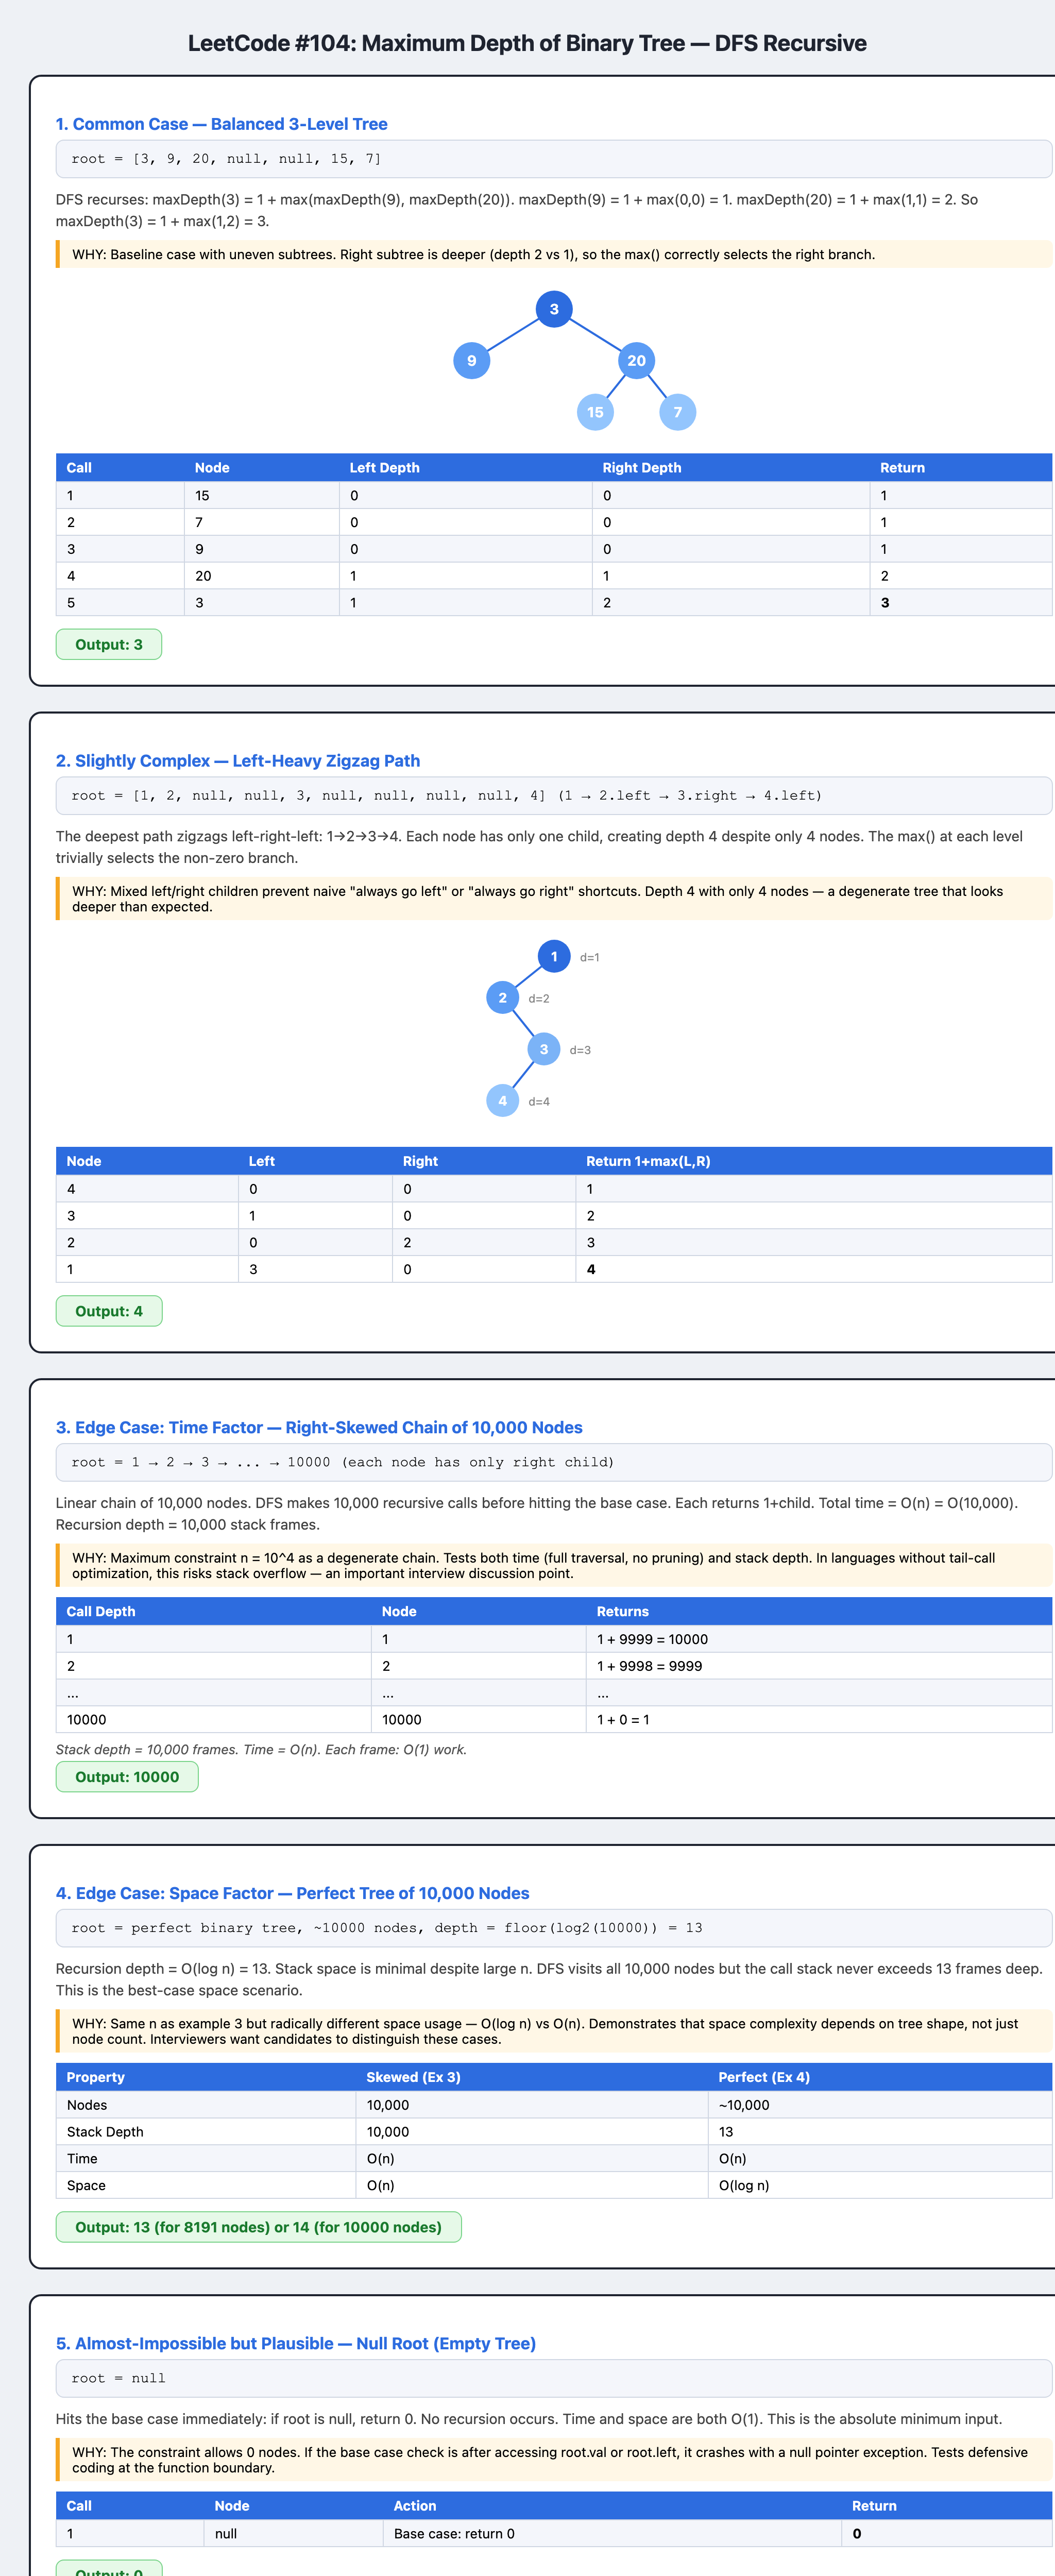